# **Lending Club Loan Data Case Study**



*   **Default** :If the applicant is not likely to repay the loan, he/she is likely to default




## **BUSINESS OBJECTIVE & PROBLEM STATEMENT**


*   **Bussiness Objective:** Lending Club is a marketplace for personal loans that matches borrowers who are seeking a loan with investors looking to lend money and make a return. When the company receives a loan application, the company has to make a decision for loan approval based on the applicant's profile. Two types of risks are associated with the bank's decision. If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company . If the applicant is not likely to repay the loan, i.e. he/she is likely to default , then approving the loan may lead to a financial loss for the company.
*   **Problem Statement:** Identify these risky loan applicants, then such loans can be reduced thereby cutting down the amount of credit loss. Identification of such applicants using EDA is the aim of this case study.



### **IMPORTING REQUIRED LIBRATIES & DATASET**

In [ ]:
import pandas as pd
import numpy as np , seaborn as sns, matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
path='/content/drive/MyDrive/lending_club_loan_clean_data.csv'
data=pd.read_csv(path)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            39717 non-null  int64  
 1   member_id             39717 non-null  int64  
 2   loan_amnt             39717 non-null  int64  
 3   funded_amnt           39717 non-null  int64  
 4   funded_amnt_inv       39717 non-null  float64
 5   term                  39717 non-null  int64  
 6   int_rate              39717 non-null  float64
 7   installment           39717 non-null  float64
 8   grade                 39717 non-null  object 
 9   sub_grade             39717 non-null  object 
 10  emp_title             39717 non-null  object 
 11  emp_length            39717 non-null  float64
 12  home_ownership        39717 non-null  object 
 13  annual_inc            39717 non-null  float64
 14  verification_status   39717 non-null  object 
 15  issue_d            

In [ ]:
data=data.drop('Unnamed: 0',axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   member_id             39717 non-null  int64  
 1   loan_amnt             39717 non-null  int64  
 2   funded_amnt           39717 non-null  int64  
 3   funded_amnt_inv       39717 non-null  float64
 4   term                  39717 non-null  int64  
 5   int_rate              39717 non-null  float64
 6   installment           39717 non-null  float64
 7   grade                 39717 non-null  object 
 8   sub_grade             39717 non-null  object 
 9   emp_title             39717 non-null  object 
 10  emp_length            39717 non-null  float64
 11  home_ownership        39717 non-null  object 
 12  annual_inc            39717 non-null  float64
 13  verification_status   39717 non-null  object 
 14  issue_d               39717 non-null  object 
 15  loan_status        

In [ ]:
data.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,pub_rec_bankruptcies,empl_length
count,3.971700e+04,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,3.971700e+04,39717.000000,39717.000000,39717.000000
mean,8.504636e+05,11219.443815,10947.713196,10397.448868,42.418007,12.021177,324.561922,4.896530,6.896893e+04,13.315130,0.042501,4.896530
std,2.656783e+05,7456.670694,7187.238670,7128.450439,10.622815,3.724825,208.874874,3.530861,6.379377e+04,6.678594,0.202603,3.530861
min,7.069900e+04,500.000000,500.000000,0.000000,36.000000,5.420000,15.690000,0.000000,4.000000e+03,0.000000,0.000000,0.000000
25%,6.667800e+05,5500.000000,5400.000000,5000.000000,36.000000,9.250000,167.020000,2.000000,4.040400e+04,8.170000,0.000000,2.000000
50%,8.508120e+05,10000.000000,9600.000000,8975.000000,36.000000,11.860000,280.220000,4.000000,5.900000e+04,13.400000,0.000000,4.000000
75%,1.047339e+06,15000.000000,15000.000000,14400.000000,60.000000,14.590000,430.780000,9.000000,8.230000e+04,18.600000,0.000000,9.000000
max,1.314167e+06,35000.000000,35000.000000,35000.000000,60.000000,24.590000,1305.190000,10.000000,6.000000e+06,29.990000,2.000000,10.000000


## **Univariate Analysis**

In [ ]:
# Function for numerical univariate analysis
def univariate_num(col,data):
  sns.set(font_scale=2)
  fig, axes=plt.subplots(1,2,figsize=(30,10),dpi=50)
  sns.boxplot(ax=axes[0],x=data[col])
  axes[0].set_title(col+" Distribution")

  sns.histplot(ax=axes[1],x=data[col] ,kde=True)
  axes[1].set_title(col+" Distribution & density")

  locs, labels=plt.xticks()
  plt.show()


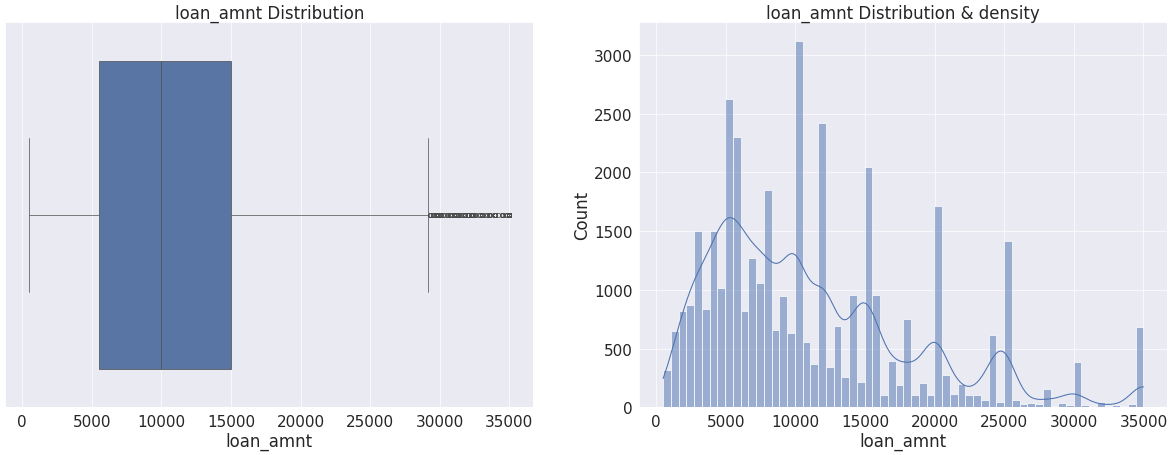

In [ ]:
univariate_num('loan_amnt',data)

## **Observation**

*   Median loan amount is around 10k, Q1(25th percentile) starts around 5000k, Q2(75th perecentile) starts around 15000k.
*   It means 50% of all loans fall in the range of $5000 to $15000.
*   There is a dense cluster of black points beyond the upper whisker,extending from 30000 to 35000.
*   These represents unusally high loan amounts compared to the rest of the dataset.
*    Right-skewed Distribution: the density curve peaks early and tapers off towards higher amounts. Most loans requested are for upper lower amounts, while larger loans are far less common.
*    $10000 is the most popular single loan amount requested(reaching over 3000 counts).




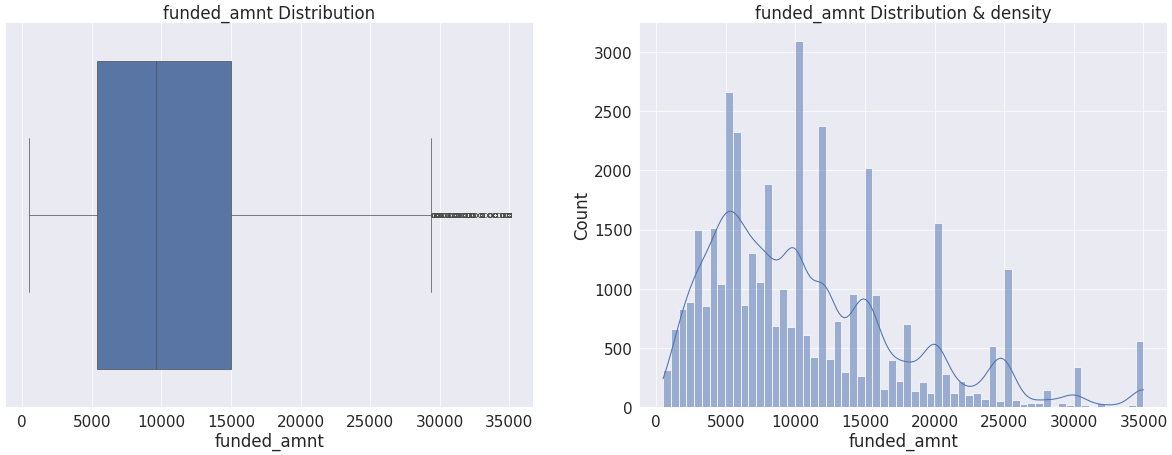

In [ ]:
univariate_num('funded_amnt',data)

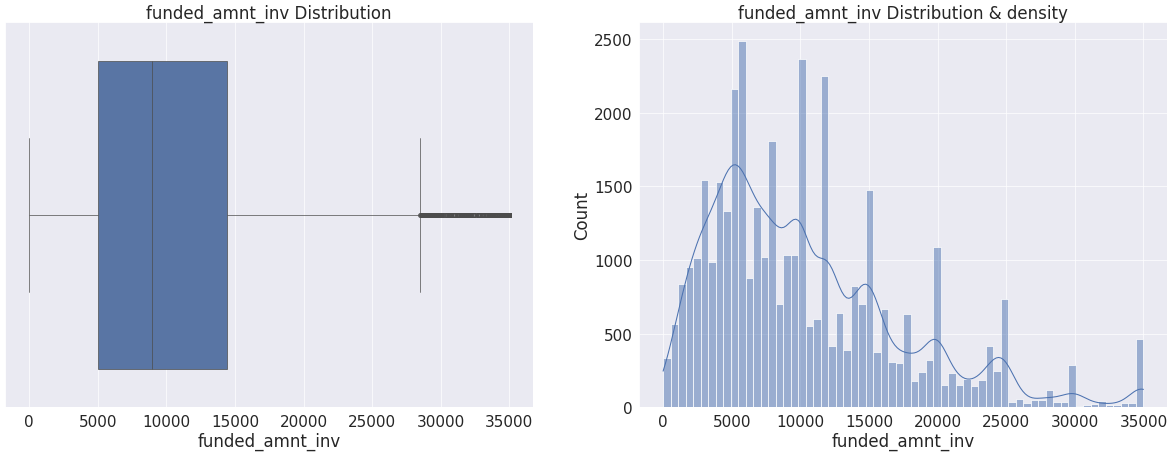

In [ ]:
univariate_num('funded_amnt_inv',data)

## **Objervation**


*   Median amounts recommeded and distributed quite close to the loan amount.
*   Right skewed distributions.
*   However, some loan amounts are not funded by investors.




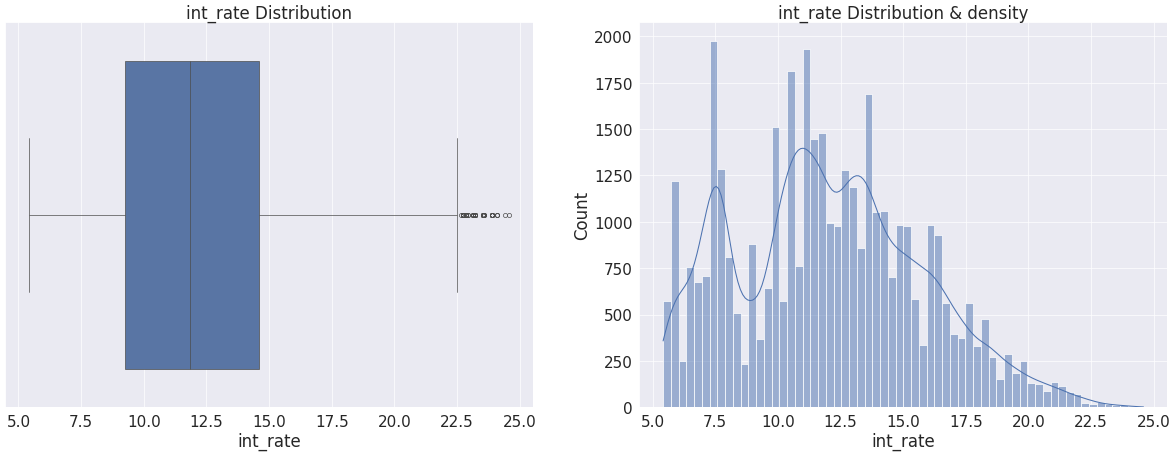

In [ ]:
univariate_num('int_rate',data)

### **Objervation**


*   Median interest rate for an application is 11.7%. 75% of values lie under 14.3%. We do notice outliers beyond 20.5% upto
*   Right skewed distribution with mean around 11.9%.



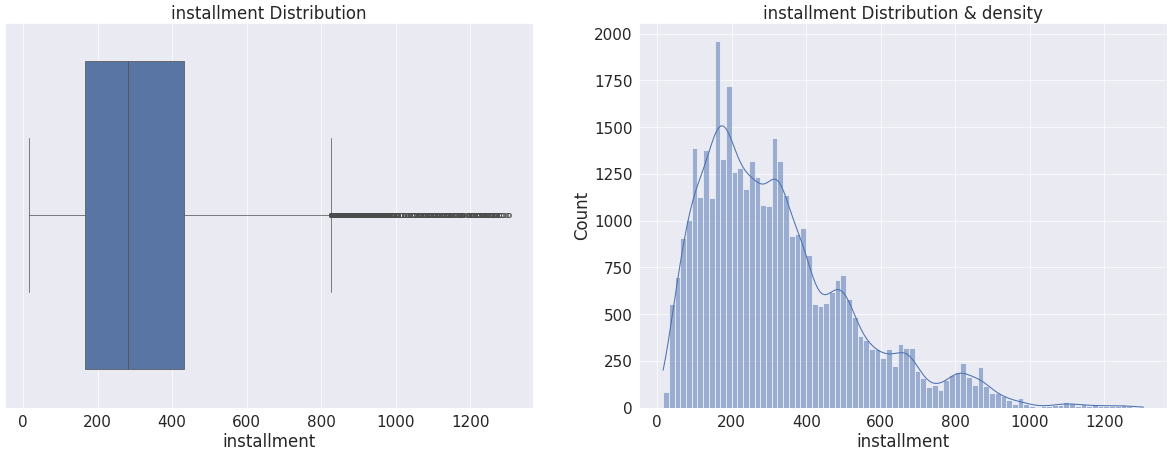

In [ ]:
univariate_num('installment',data)

### **Observations**


*   Right skewed distribution with mean around 322
*   We can also see outliers beyond 500



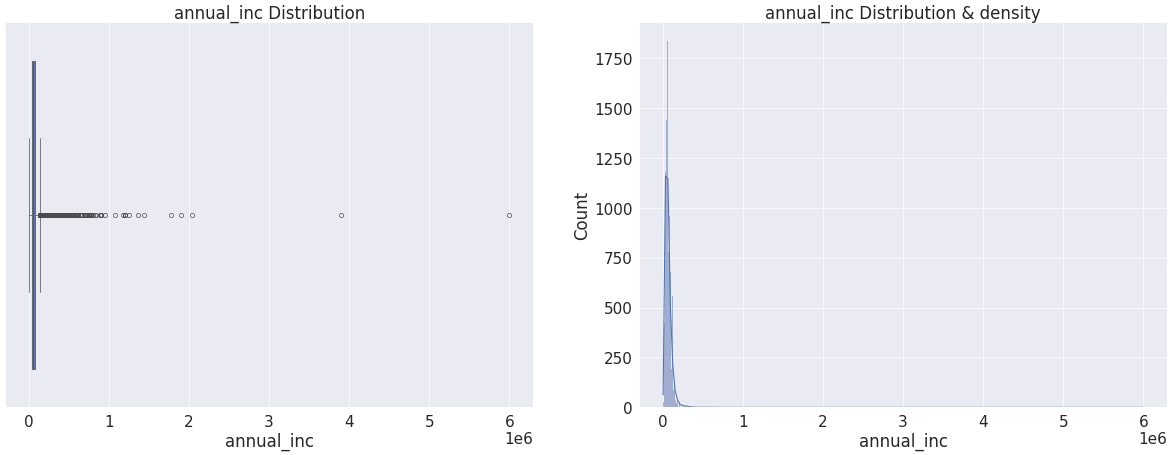

In [ ]:
univariate_num('annual_inc',data)



*   Right skewed and has a couple of outliers.
*   need to convert the annual income into ranges for better analysis.



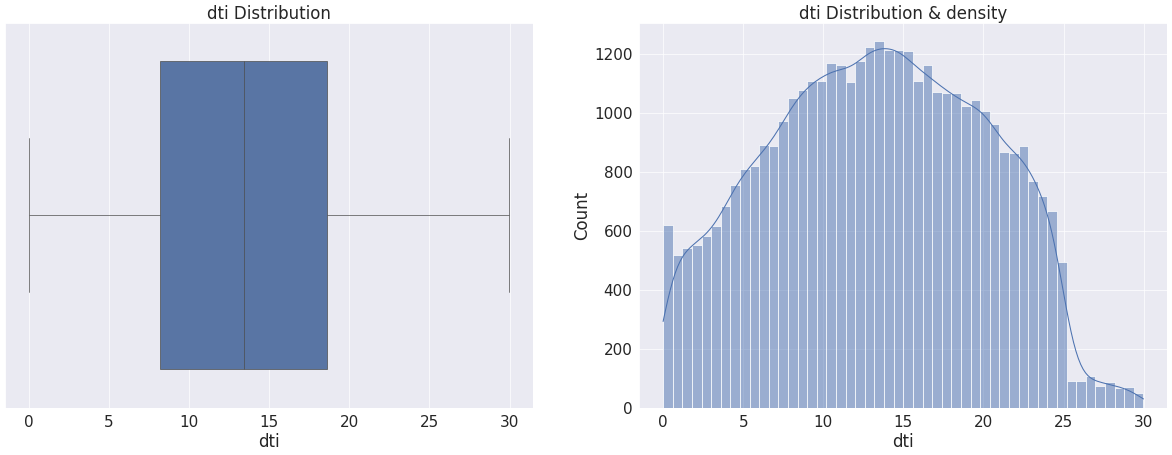

In [ ]:
univariate_num('dti',data)

### **Objservations**


*   seems like normal distribution.
*   No outliers.



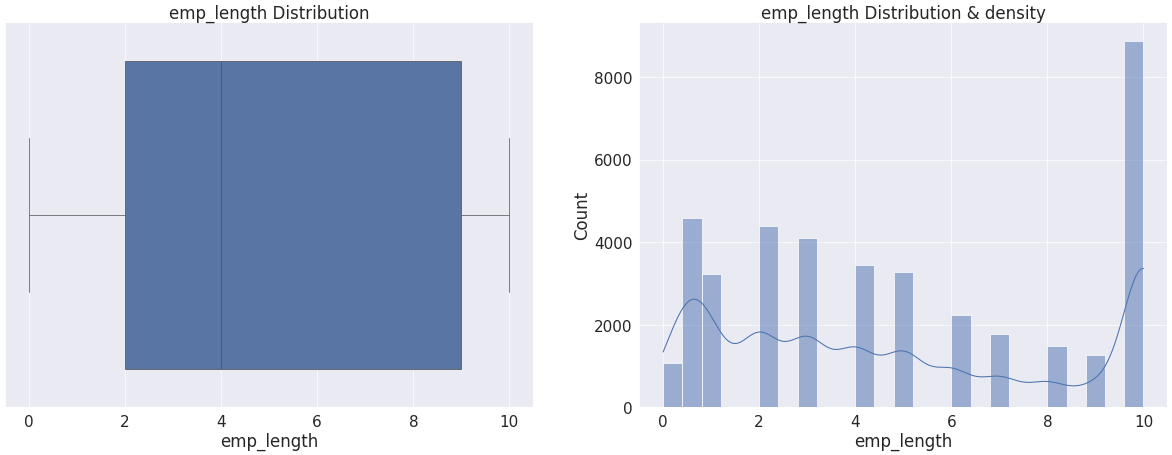

In [ ]:
univariate_num('emp_length',data)

### **Observatons**


*   The middle 50% of employees have an employment length between 2 to 9 years, with a median employment length of around 4 years. There are no visible outliers beyond the minimum and maximum.
*   Massive Spike at 10 years



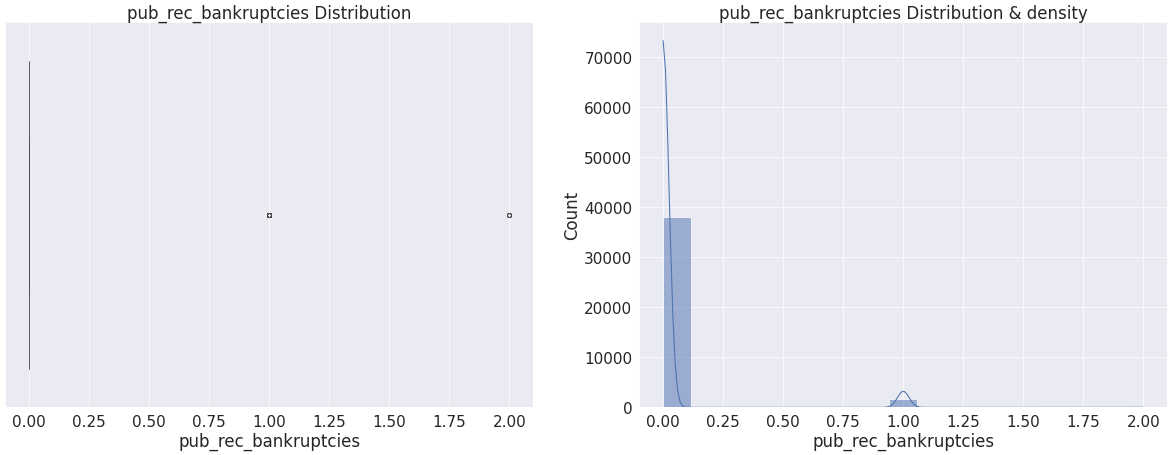

In [ ]:
univariate_num('pub_rec_bankruptcies',data)



*   Most of the members do not have a history of bankruptcy




In [ ]:
# Building a function to generate univariate categroies
def univariate_cat(col,loan_new):
    sns.set(font_scale=1)
    plt.figure(figsize=[10,5])
    ax=sns.countplot(x=loan_new[col], data=loan_new)
    plt.title(col+ ' distribution')
    #add_value_labels(ax)
    plt.xticks(rotation=90)
    plt.show()

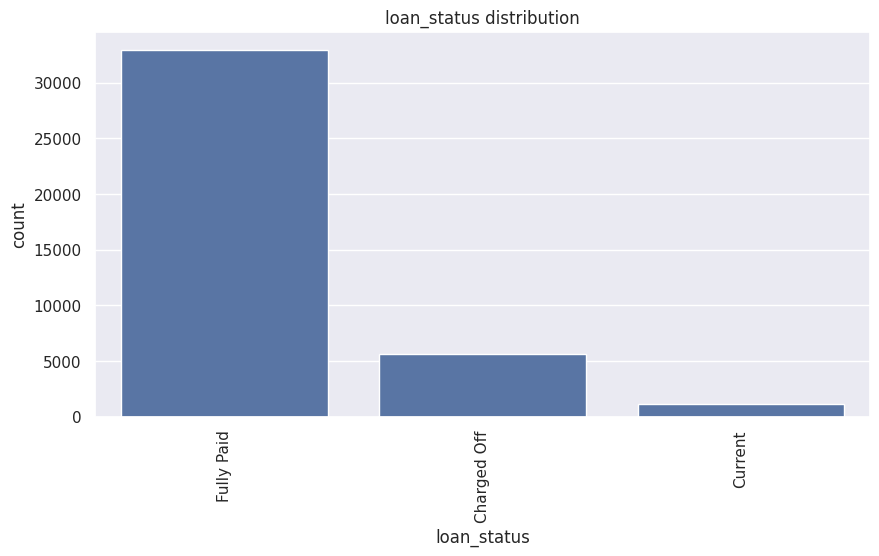

In [ ]:
univariate_cat('loan_status',data)

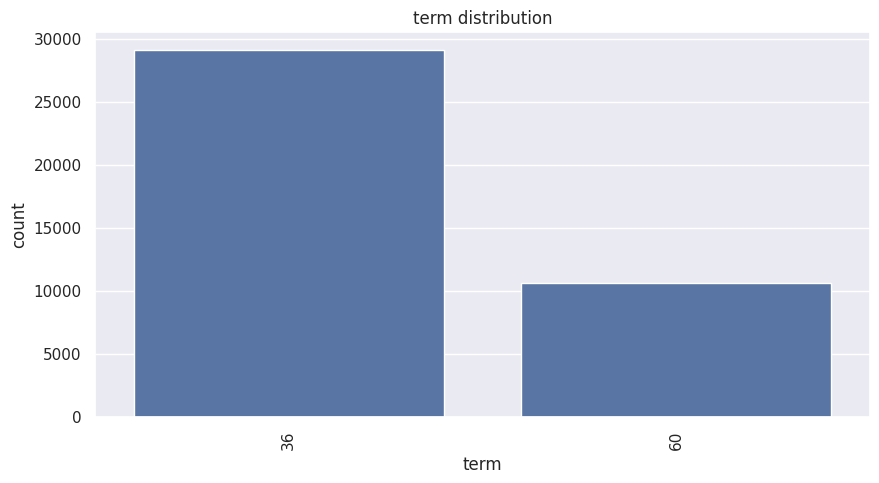

In [ ]:
univariate_cat('term',data)

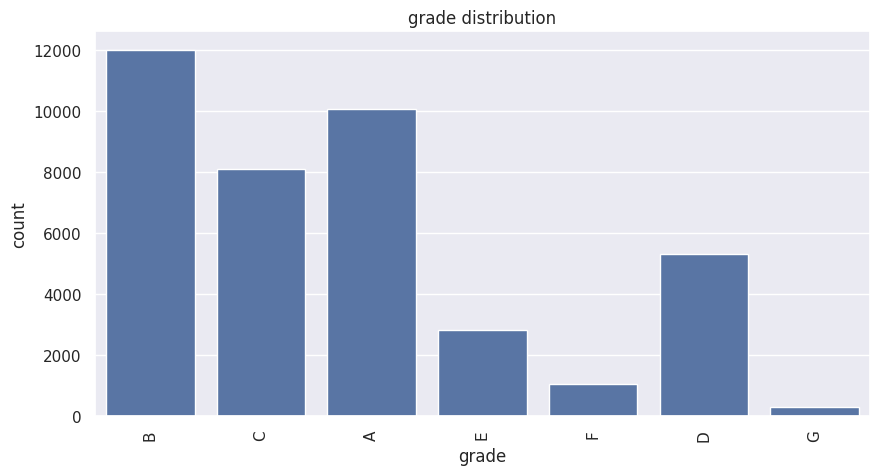

In [ ]:
univariate_cat('grade',data)

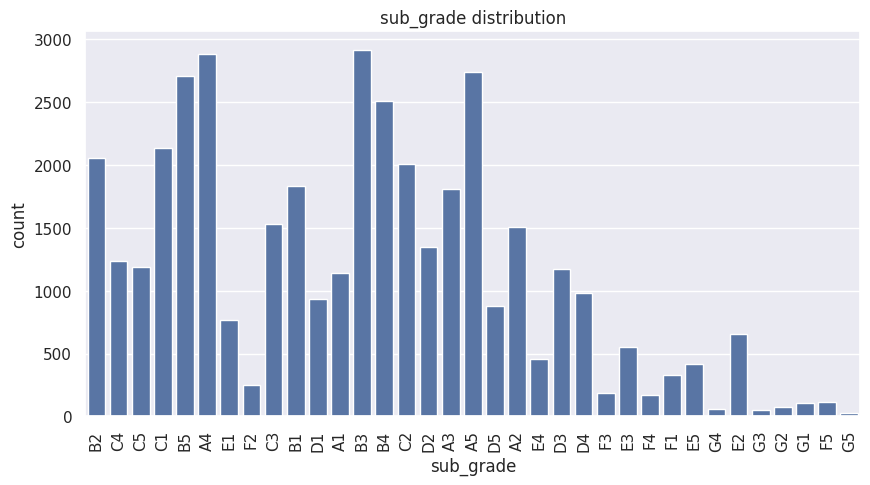

In [ ]:
univariate_cat('sub_grade',data)

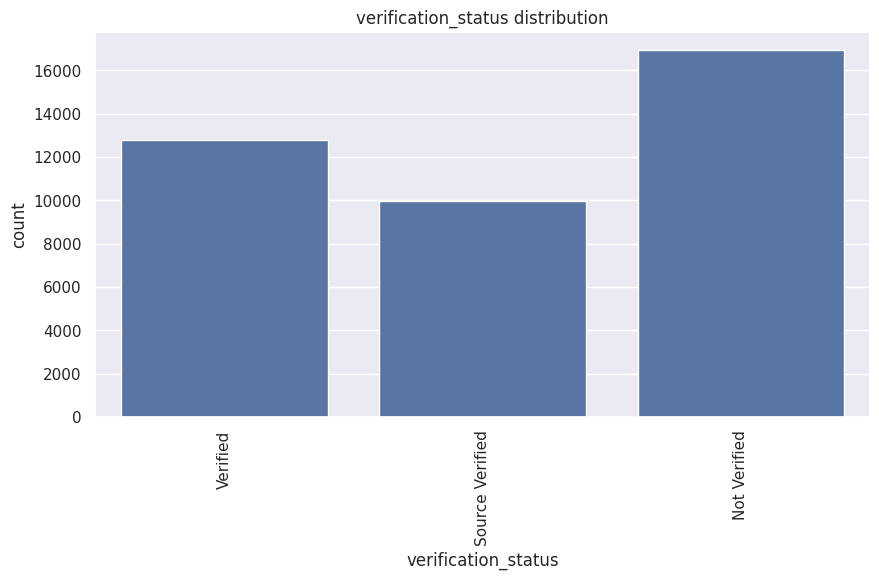

In [ ]:
univariate_cat('verification_status',data)



*   A large amount of the loan application apprear to be in the unverified category.



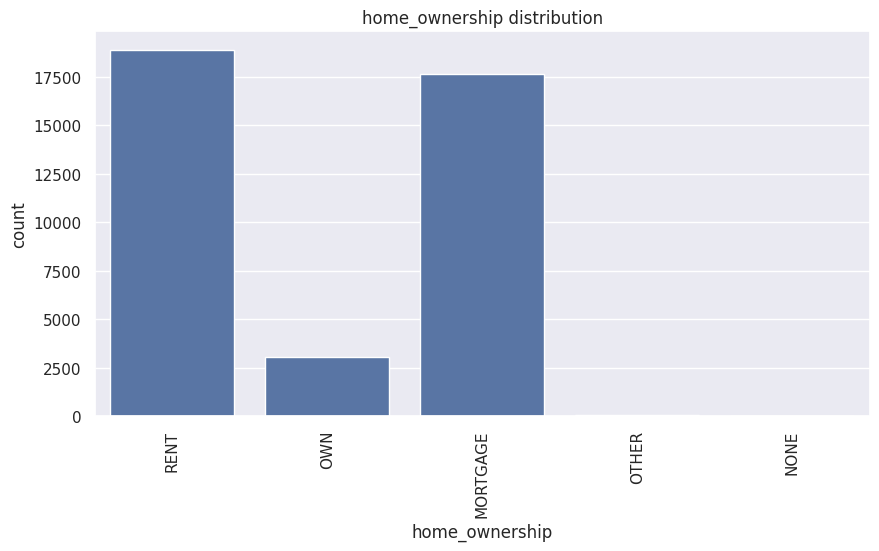

In [ ]:
univariate_cat('home_ownership',data)



*   Maximun amound of loan application either have a mortagage or are on rent.



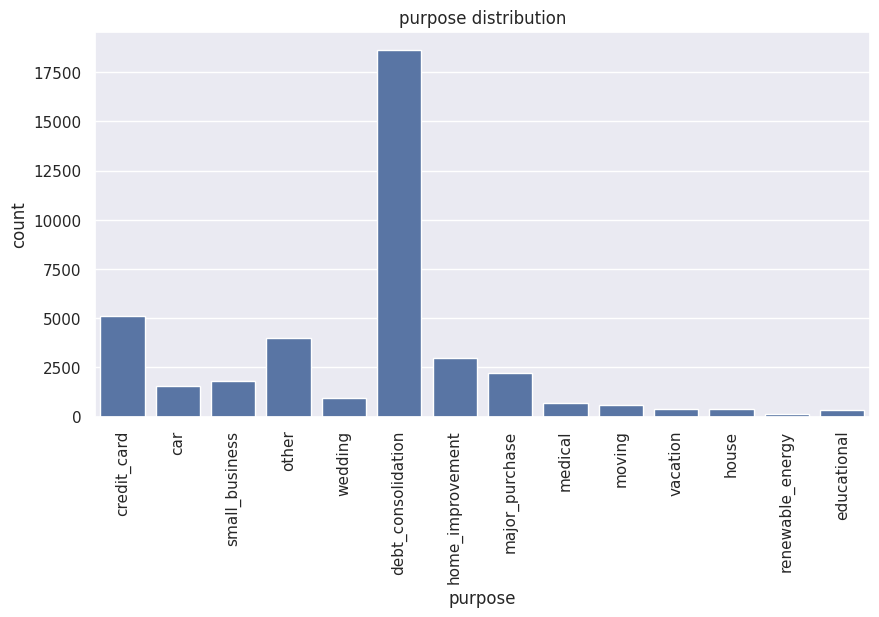

In [ ]:
univariate_cat('purpose',data)

About 22.5K representing 60% of the loans have been consumed for debt (includes credit)consolidation / addressing debt
Most of the categories except small business appear to be personal loans

<Axes: xlabel='zip_code'>

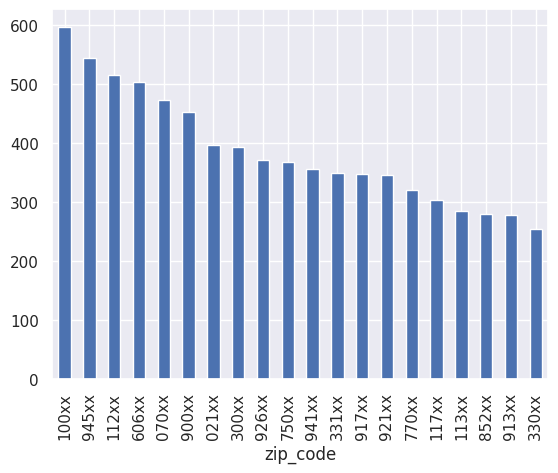

In [ ]:
data['zip_code'].value_counts().nlargest(20).plot.bar()

Specific zip codes will tend to have higher consumption, disposable incomes versus certain others. There could be a direct or an inverse correlation based on necessity for loan vs. using the loan for discretionary spending

In [ ]:
# Defining a function to generate bi variate analyses between the target and the chosen categorical variables
def plot_stats(feature,label_rotation=False,horizontal_layout=True):
    sns.set(font_scale=1)
    temp = data[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index,'Number of Applications': temp.values})

    # Calculate the percentage of loan_status_new =1 per category value
    cat_perc = data[[feature, 'loan_status_new']].groupby([feature],as_index=False).mean()
    cat_perc.sort_values(by='loan_status_new', ascending=False, inplace=True)
    sns.set_style("whitegrid")


    if(horizontal_layout):
        sns.set(font_scale=1.5)
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20,5))
    else:
        sns.set(font_scale=1.5)
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(20,10))

    sns.set_color_codes("pastel")
    sns.set_style("whitegrid")

    s = sns.barplot(ax=ax1, x = feature, y="Number of Applications",data=df1)

    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)

    #s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=cat_perc[feature], data=cat_perc)
    s = sns.barplot(ax=ax2, x = feature, y='loan_status_new', data=cat_perc)

    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)

    plt.ylabel('Percent of charged Off [%]')

    plt.tick_params(axis='both', which='major')
    plt.subplots_adjust(wspace=0.2, top=0.9)
    plt.show();

In [ ]:
# New column addition to display the target variable as a numeric value
data['loan_status_new']= data['loan_status'].map({'Charged Off':1,'Fully Paid':0})

/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


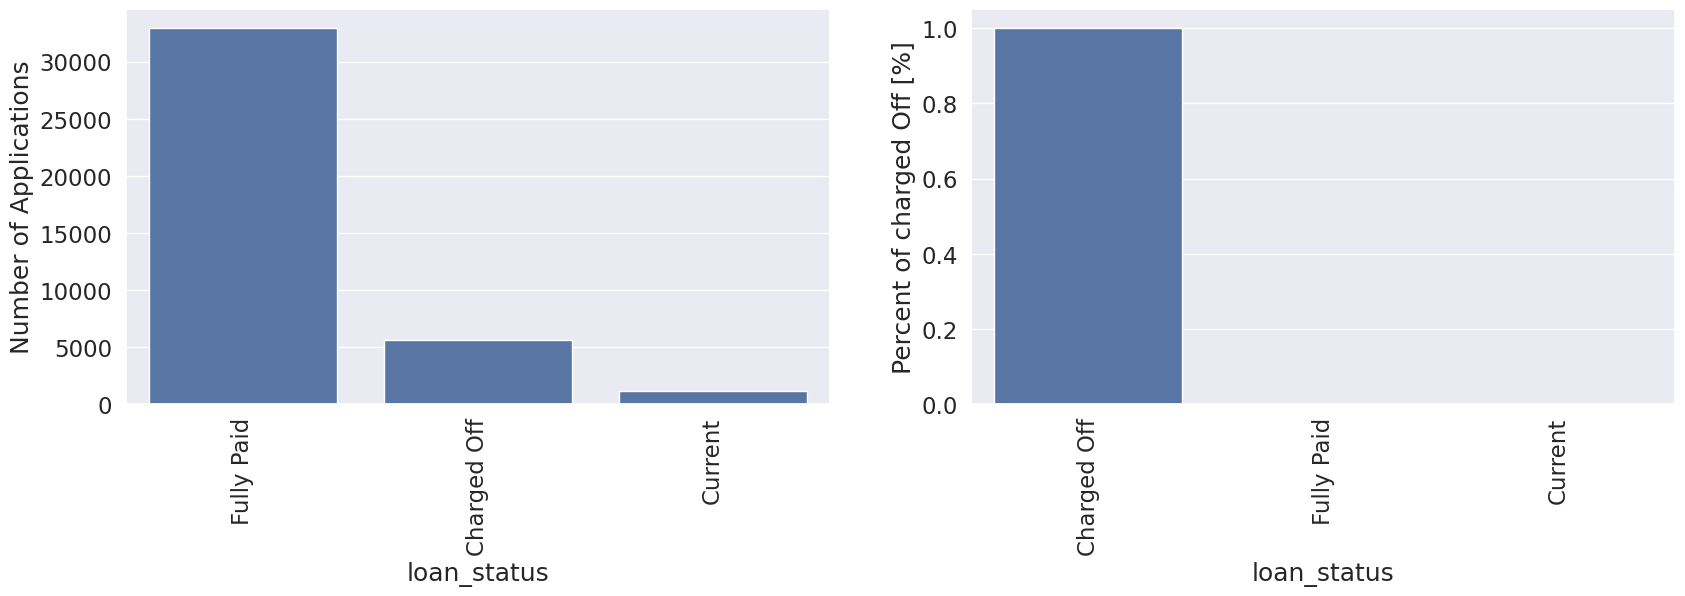

In [ ]:
plot_stats('loan_status',True)



*   **About 13% charge offs exist when comparing full paid and chaegeoffs**




/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


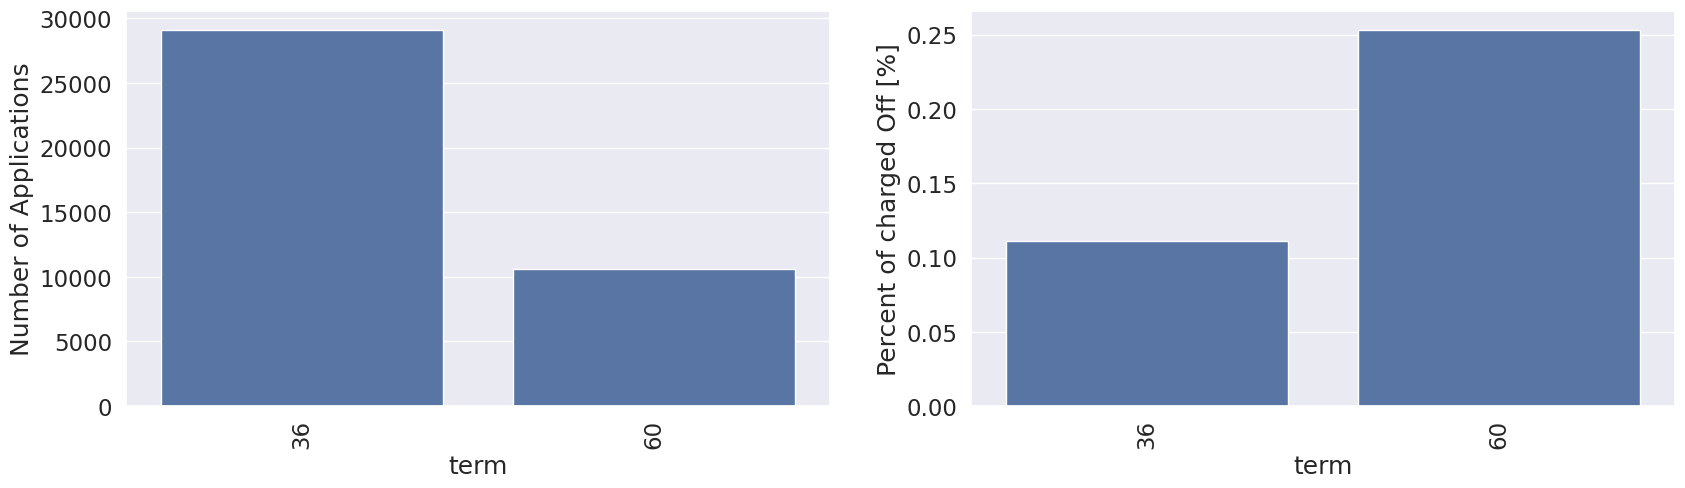

In [ ]:
plot_stats('term',True)



*   **Higher term leads to higher charge off. As the term goes up the default risk increses.**



In [ ]:
data['int_rate_cat']= pd.cut(data['int_rate'], bins= 5)

In [ ]:
data['annual_inc_cat']= pd.qcut(data['annual_inc'], q=5)

In [ ]:
data['emp_length_cat']= pd.cut(data['emp_length'], bins= 5)

In [ ]:
data['loan_amnt_cat']= pd.cut(data['loan_amnt'], bins= 5)

/tmp/ipykernel_589/3087534489.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_perc = data[[feature, 'loan_status_new']].groupby([feature],as_index=False).mean()
/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


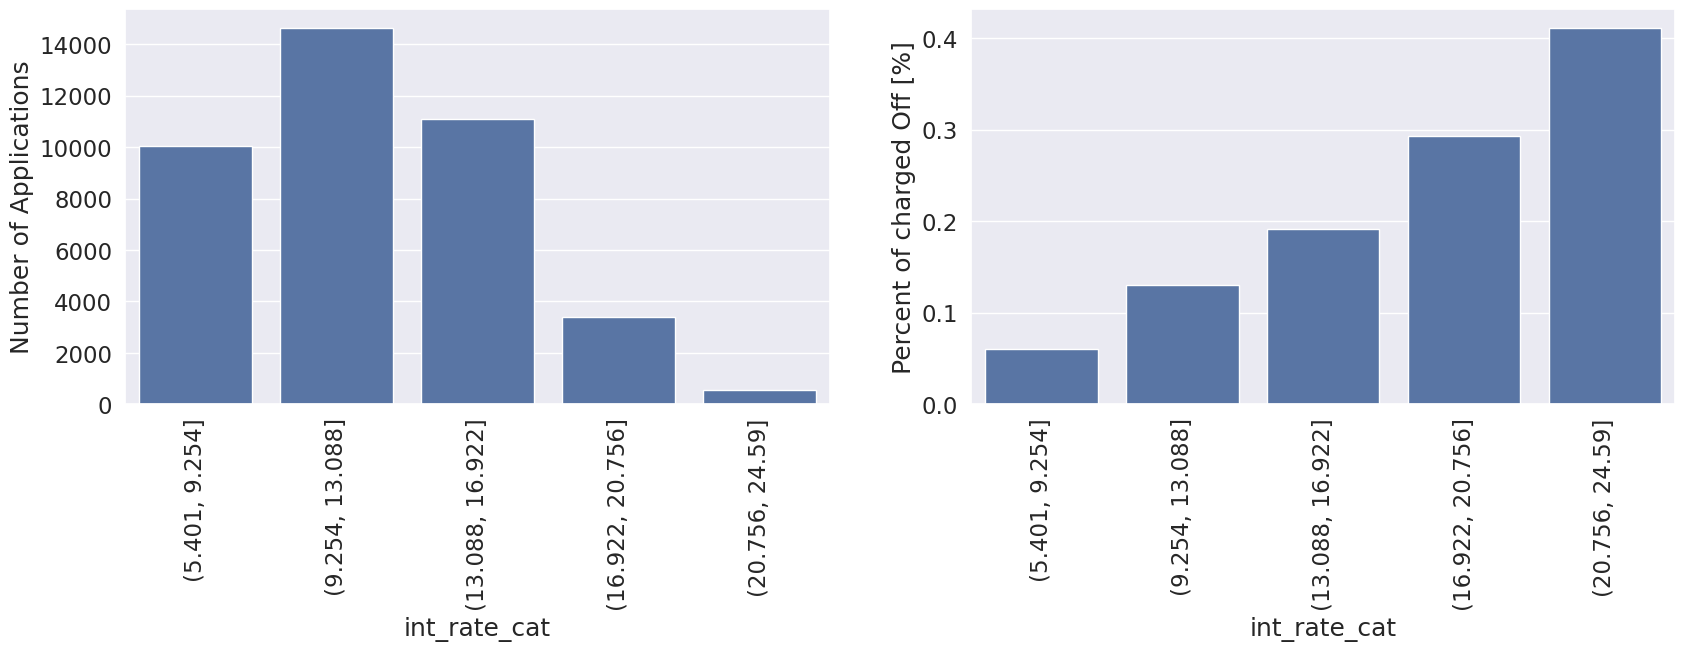

In [ ]:
plot_stats('int_rate_cat',True)

### **Observation**


*   As the interest rate increases,charge off increses


/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


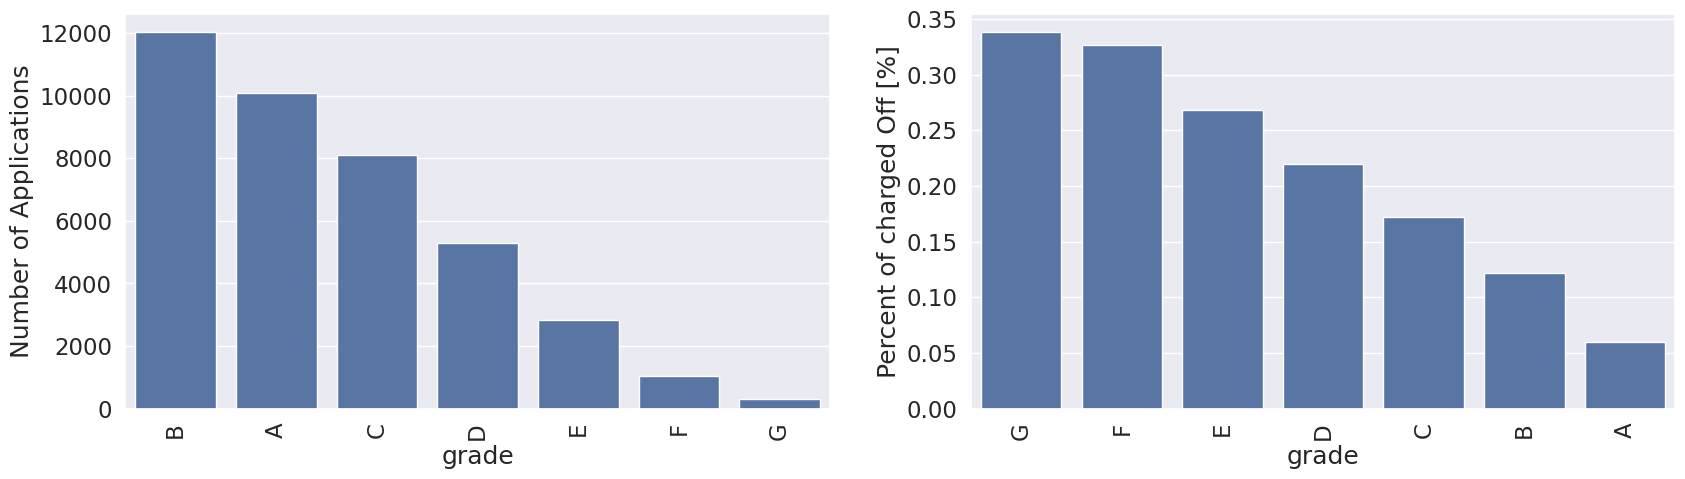

In [ ]:
plot_stats('grade',True)

### **Observation**


*   The lower investement grades have a higher charge off percentage. It is a quite accurate as a predictor of loan default



/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


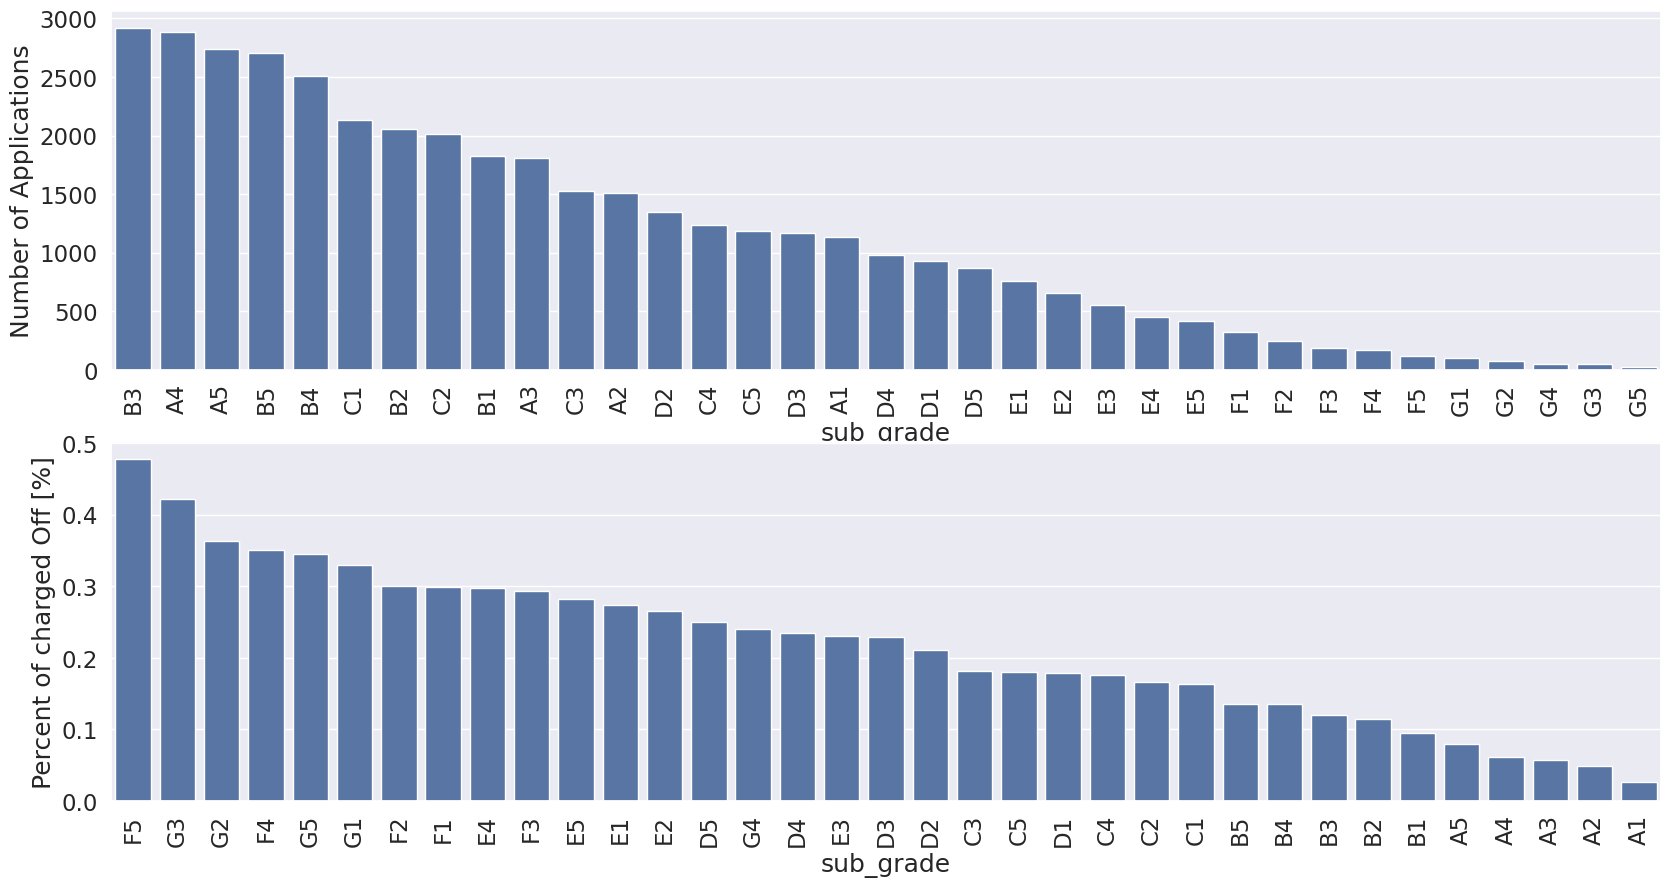

In [ ]:
plot_stats('sub_grade',True,False)

/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


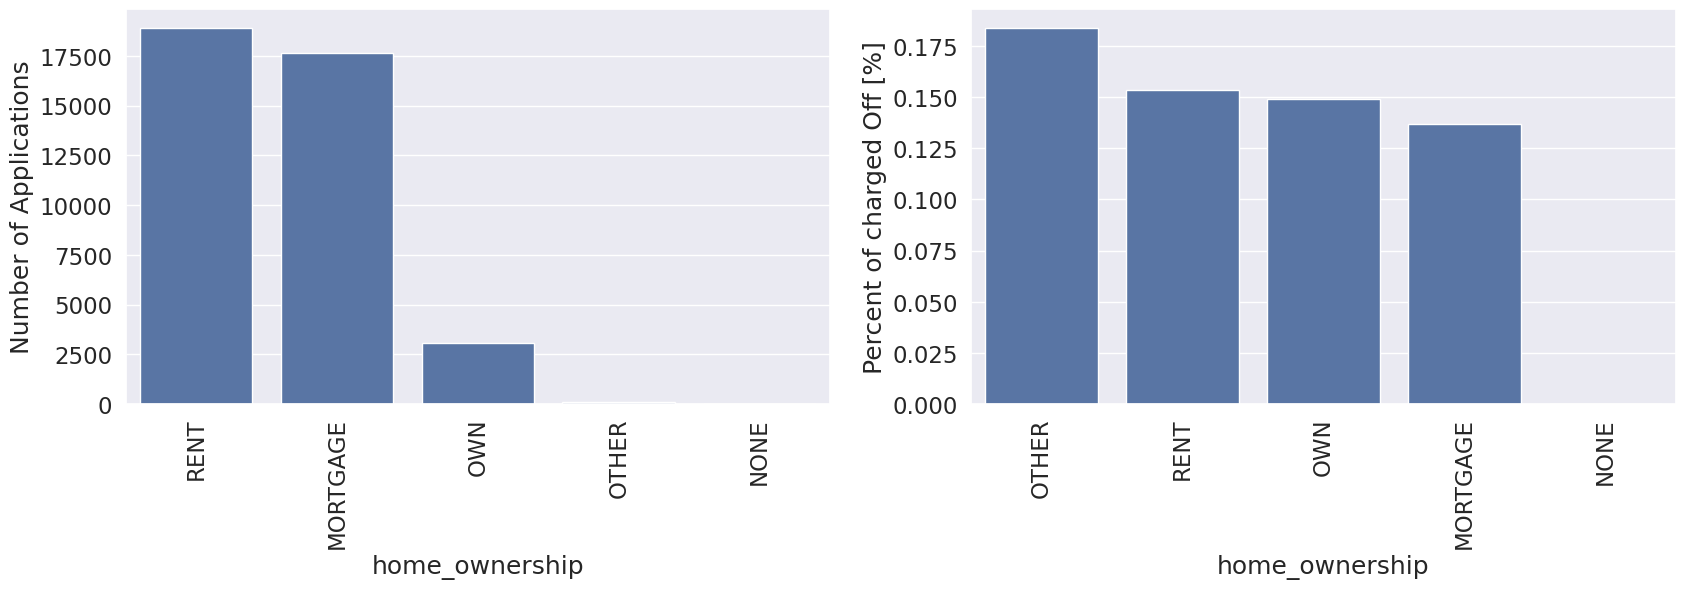

In [ ]:
plot_stats('home_ownership',True)

### **Observations**


*   The category other is low however high default rate.
*   Rend and mortage has also quite high default rate.



/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


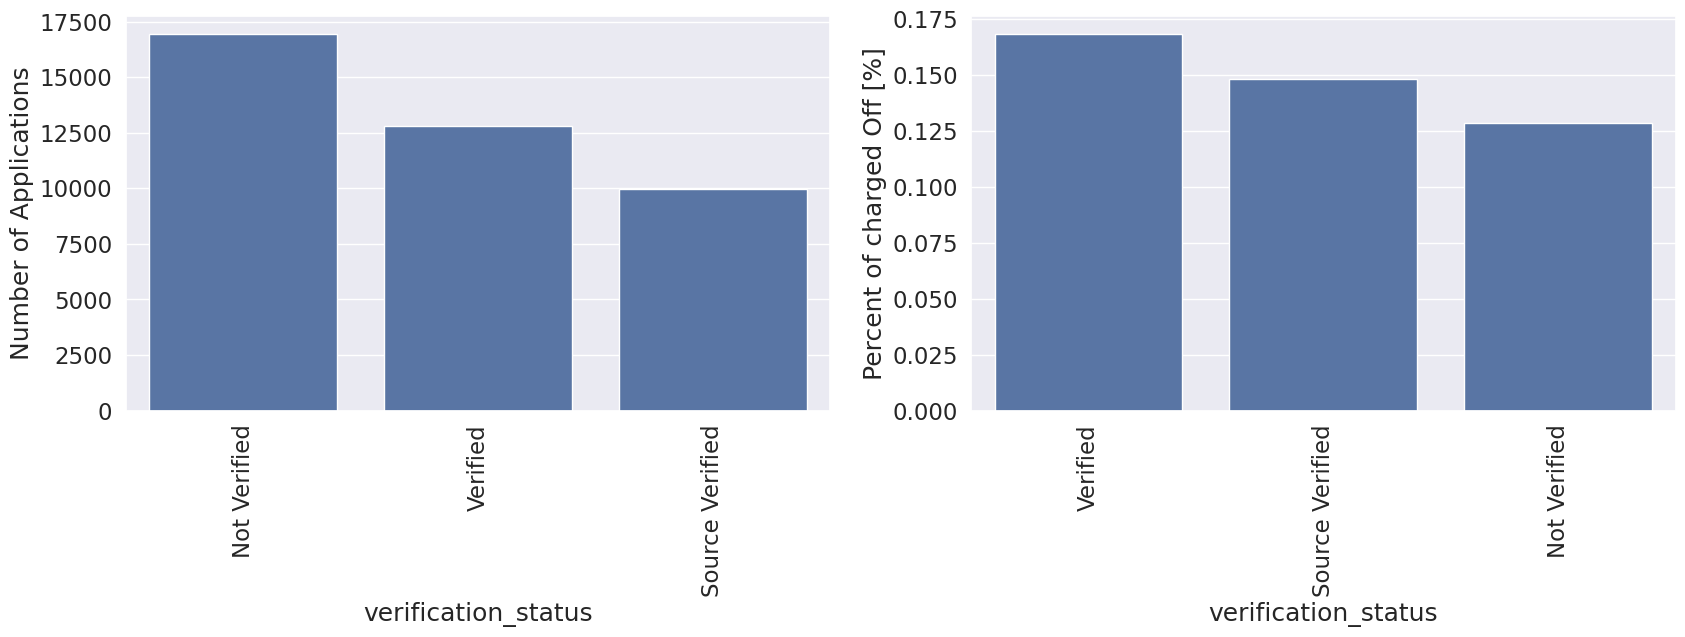

In [ ]:
plot_stats('verification_status',True)



*   **Not verified category are high and also the same time they have lower default rate compare to others.**
*  **All categories have a default rate.**



/tmp/ipykernel_589/3087534489.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_perc = data[[feature, 'loan_status_new']].groupby([feature],as_index=False).mean()
/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


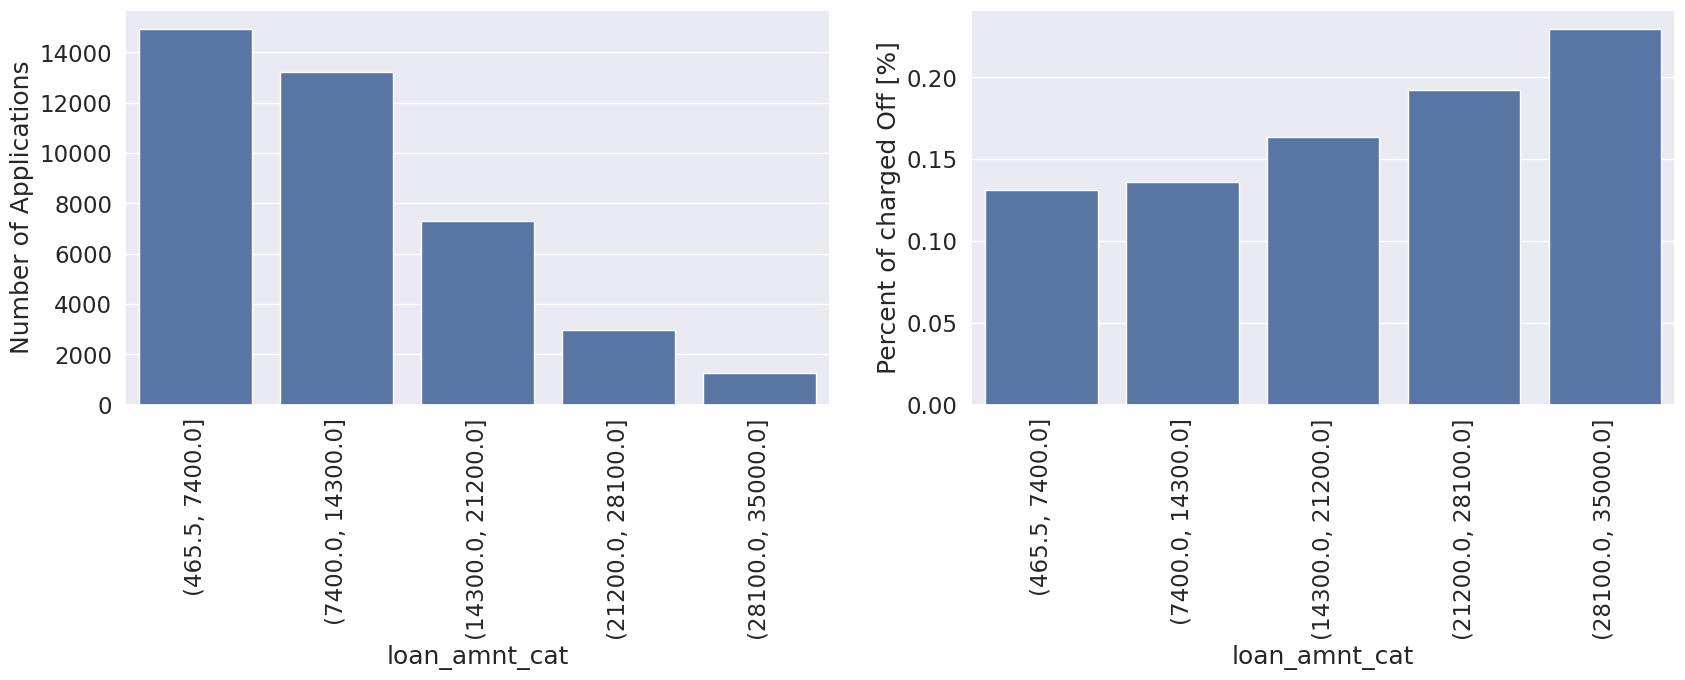

In [ ]:
plot_stats('loan_amnt_cat',True)



*   **Higher the loan amount, smaller the loan pool greater the default risk. Capping the loan amounts < 20K can potentially reduce default risk at the surface but could spread the default risk to lower categories of loan amounts**



/tmp/ipykernel_589/3087534489.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_perc = data[[feature, 'loan_status_new']].groupby([feature],as_index=False).mean()
/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


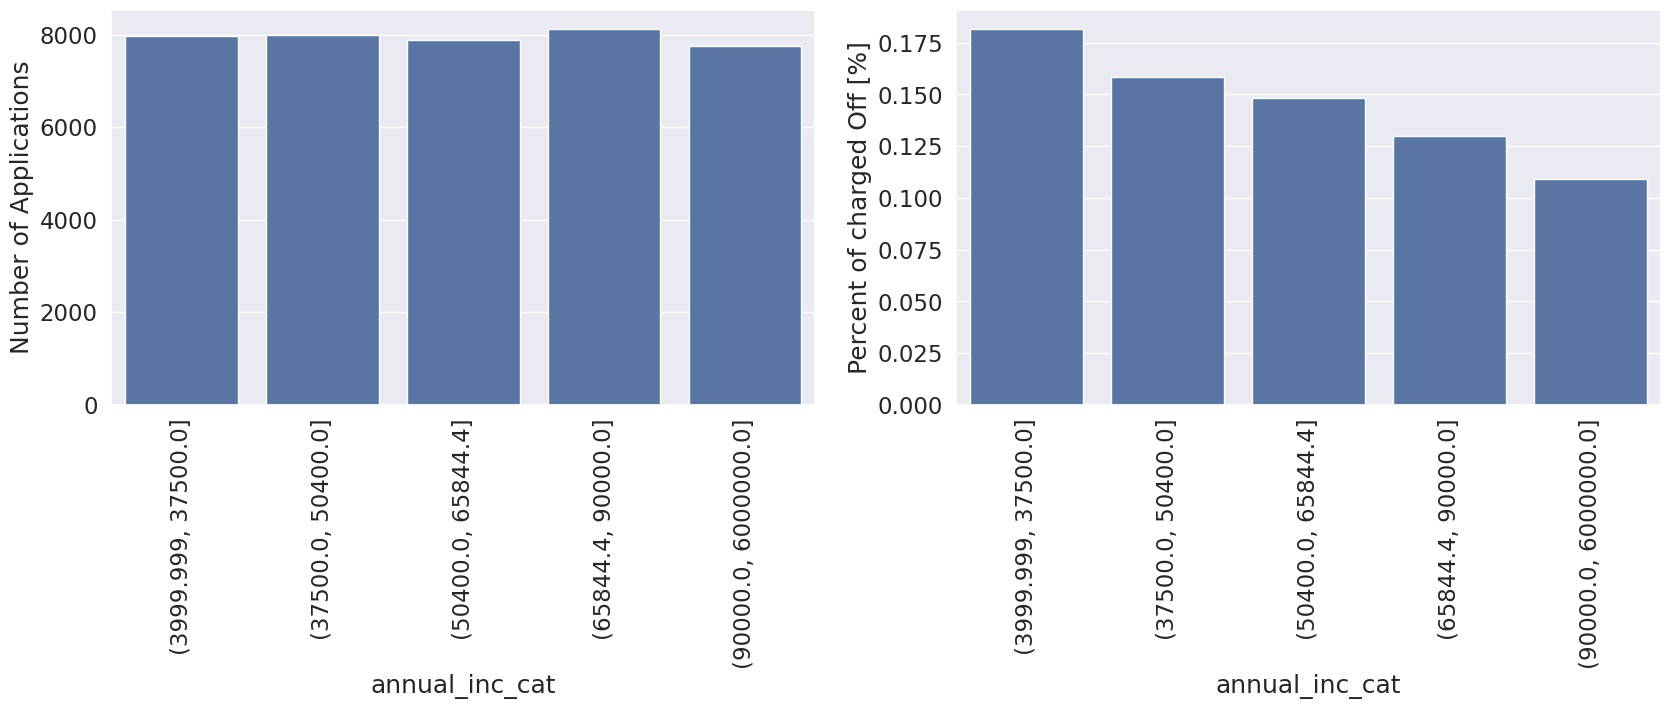

In [ ]:
plot_stats('annual_inc_cat',True)



1.   **Lower the annual income rate have higher the default risk. However all the income category have quite numbers of applicant.**



/tmp/ipykernel_589/3087534489.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_perc = data[[feature, 'loan_status_new']].groupby([feature],as_index=False).mean()
/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


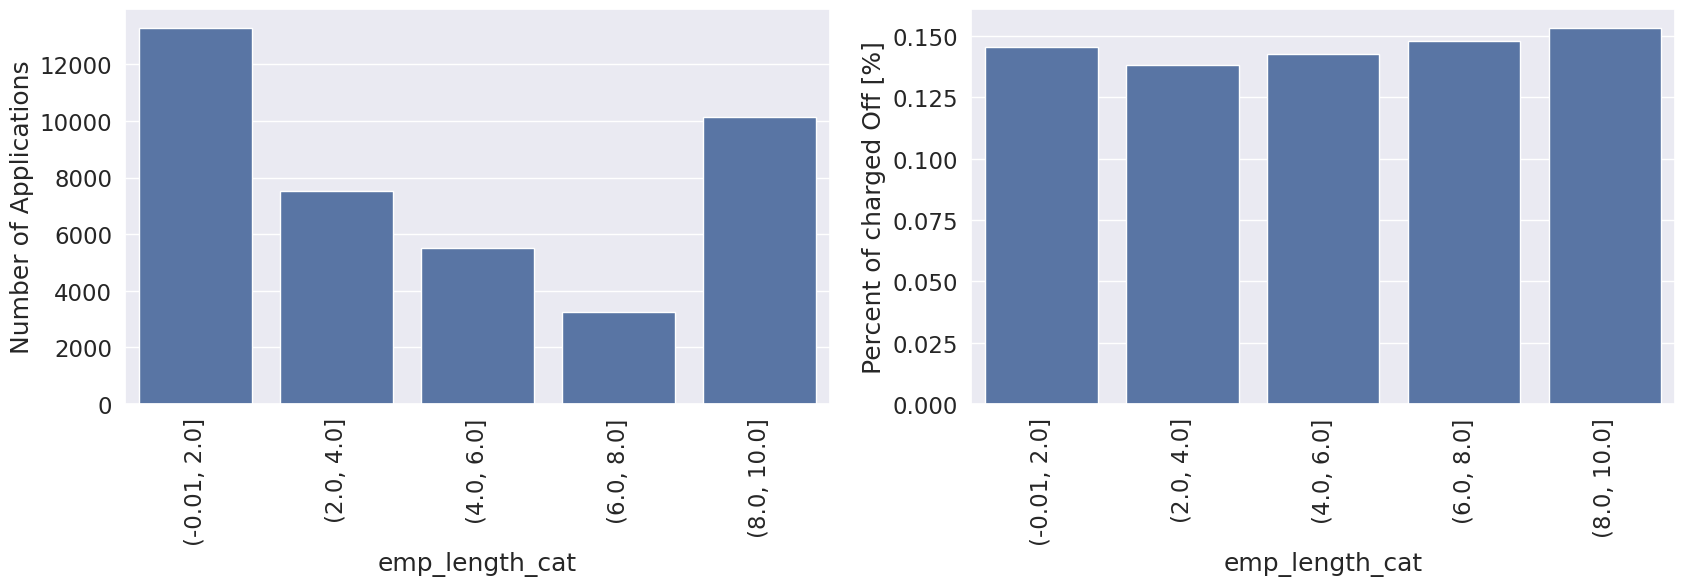

In [ ]:
plot_stats('emp_length_cat',True)



1.   **There is similar default rates across all emp lengths though their population share is low. Therefore the emp length may not be a significant parameter to judge default risk**



/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


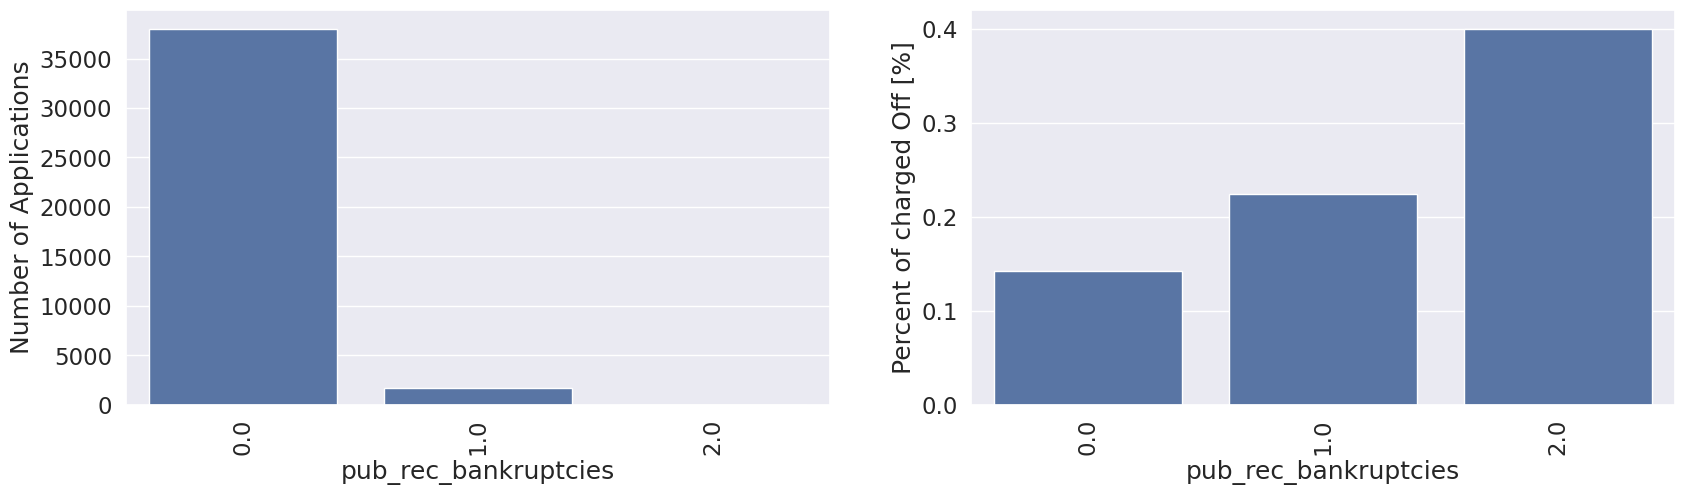

In [ ]:
plot_stats('pub_rec_bankruptcies',True)



*   From the data it is clear that though the volume of applicants with public record of bankrupcties is low, there is a strong propensity for default based on the bankruptcy record of the applicant.
lending club can stop providing loans to such members.



/tmp/ipykernel_589/3087534489.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)
/tmp/ipykernel_589/3087534489.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


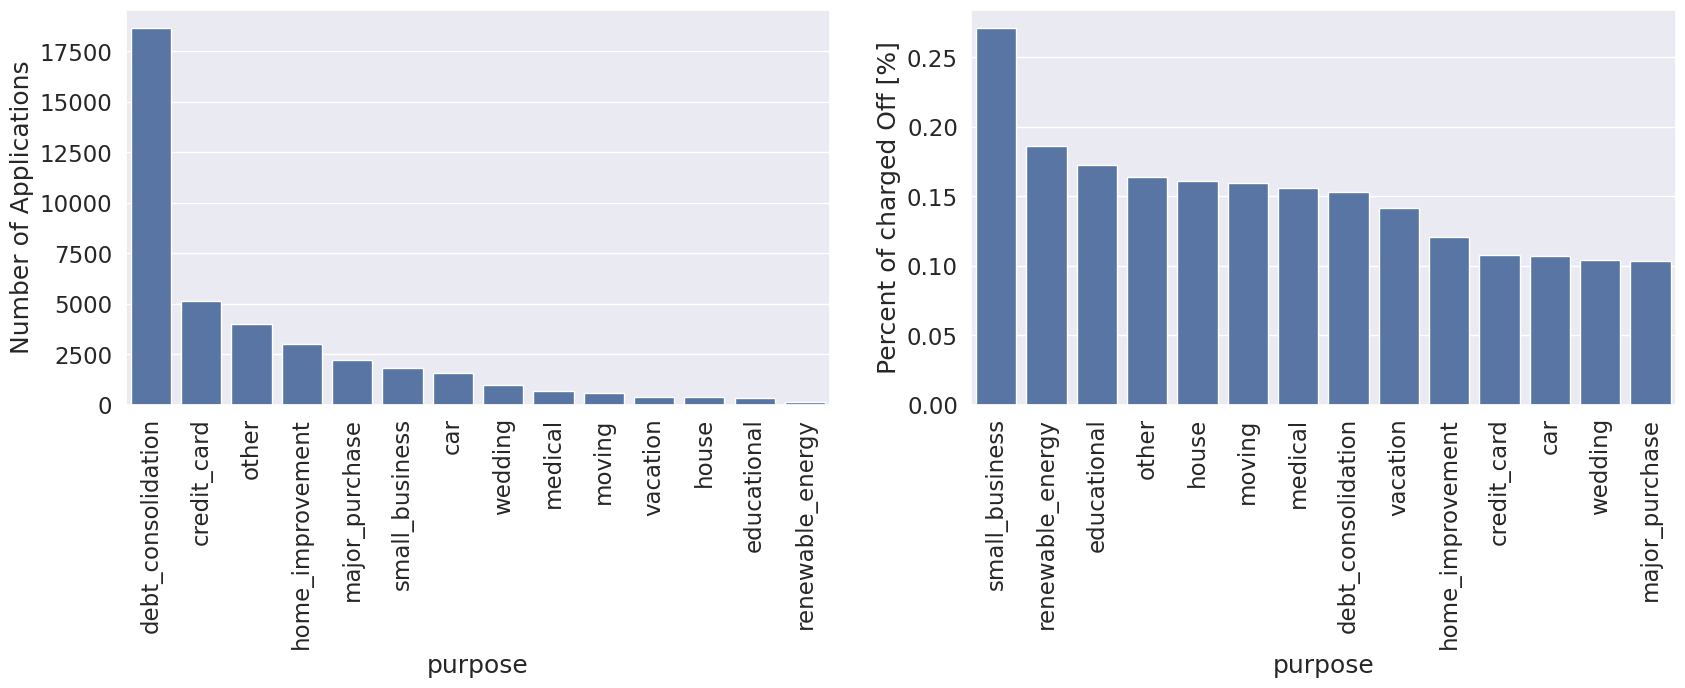

In [ ]:
plot_stats('purpose',True)



*   Small business loans also feature in the 6th position with the hihest default rate.



#**Key Drivers of Loan Charge-Offs**
Analyzing the structure and statistics of the Lending Club dataset reveals several primary risk indicators that strongly correlate with borrower default and loan charge-offs:

*  **Loan Term (term):** Longer loan durations (60 months vs. 36 months) significantly increase default risk. Over a longer period, borrowers face a higher likelihood of experiencing personal financial shocks (e.g., job loss, economic downturns).

*  **Interest Rate & Installment (int_rate, installment)**:Higher interest rates directly increase the monthly payment burden. Borrowers assigned higher interest rates (often due to sub-grade classifications) have a markedly higher rate of charge-off.

*  **Debt-to-Income Ratio (dti):** A high DTI indicates that a large portion of the borrower's income goes toward servicing existing debt. Borrowers with elevated DTI ratios have limited financial flexibility when unexpected expenses arise.

*  **Credit Grade / Sub-Grade (grade, sub_grade):** Risk-based pricing places higher-risk applicants into lower grades (e.g., Grades E, F, G). These grades historically exhibit the highest charge-off rates compared to Grades A and B.

*  **Annual Income (annual_inc):** Lower annual income limits a borrower's capacity to absorb financial stress, making them more sensitive to high installment amounts.

*  **Public Record Bankruptcies** (pub_rec_bankruptcies): Borrowers with prior bankruptcies on public record present a significantly higher baseline probability of default.

*  **Loan Purpose (purpose):** High-risk loan categories—such as small business loans or credit card consolidation with high existing balances—tend to have higher charge-off rates compared to lower-risk categories like major purchases or home improvement.

##**Strategic Recommendations**
To reduce credit loss and improve overall portfolio performance, Lending Club should consider the following underwriting and risk-management strategies:

*  Risk-Based Underwriting & Policy Caps
Cap Debt-to-Income (DTI) for Long-Term Loans: Implement stricter DTI limits specifically for 60-month loans to ensure borrowers are not over-leveraged over extended horizons.

*  Stricter Verification for High Risk Grades: Require mandatory income and employment verification for lower loan grades (E, F, G) and high loan amounts.

*  Previous Bankruptcy Restrictions: Set tighter credit limits or demand higher credit scores for applicants with any history of public record bankruptcies.

##**Product & Pricing Strategy**
*  Tiered Loan Amounts by Income: Introduce income-to-loan-amount caps (e.g., limiting maximum loan size to a specific percentage of annual income) to prevent excessive installment-to-income stress.

*  Adjust Pricing for High-Risk Categories: Re-evaluate interest rate pricing or loan eligibility for inherently riskier loan purposes, such as small business financing.
